# Nutrition & Food Habit Exploration

Load MacroFactor data and explore food habits, macro trends, and diet patterns.

In [20]:
import sys
sys.path.insert(0, '../scripts')
from load_data import load_nutrition, top_foods, food_stats, daily_macros
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [21]:
nutrition = load_nutrition()
nutrition['date'] = nutrition['Date'].dt.date
nutrition.head()

,Date,Time,Food Name,Serving Size,Serving Qty,Serving Weight (g),Calories (kcal),Fat (g),Carbs (g),Protein (g),...,Tyrosine (g),Valine (g),Vitamin A (mcg),Vitamin C (mg),Vitamin D (mcg),Vitamin E (mg),Vitamin K (mcg),Water (g),Zinc (mg),date
0,2025-09-18,10:29 AM,Huel Ready-to-Drink Black Edition Chocolate,bottle,1.0,500.00,400,17.0,30.0,35.0,...,NaN,NaN,180.0,50.0,5.0,3.0,35.0,NaN,4.0,2025-09-18
1,2025-09-18,11:25 AM,Espresso,shot or solo - each 1 FO,1.0,29.60,3,0.0,0.0,0.0,...,NaN,NaN,NaN,0.1,NaN,0.0,0.0,29.0,0.0,2025-09-18
2,2025-09-18,11:26 AM,2% Reduced Fat Milk,ml,240.0,0.42,130,5.0,13.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-18
3,2025-09-18,01:27 PM,Sesame Soy Tofu Yakisoba,bowl,2.0,450.00,880,29.0,117.0,57.0,...,1.8,2.8,652.4,178.0,NaN,4.0,259.1,765.0,4.9,2025-09-18
4,2025-09-18,03:00 PM,Organic Coconut Water,ml,414.0,0.24,110,0.0,27.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-18


## Food Habits

In [22]:
# Top foods last 7 days
print("Top 10 foods (last 7 days):")
print(top_foods(nutrition, days=7))

Top 10 foods (last 7 days):
Food Name
Reduced Fat Ultra-Filtered Milk             8
Banana, Fresh                               4
Creatine Monohydrate                        4
Sharp White Cheddar                         3
Organic Fresh Medjool Dates                 3
Orange                                      3
Peanut Butter Dark Chocolate                2
Free Range Large Brown Eggs With Omega-3    2
Organic High Protein Tofu Super Firm        2
Organic Soy Sauce - Less Sodium             2
Name: count, dtype: int64


In [23]:
# Top foods last 30 days
print("\nTop 10 foods (last 30 days):")
print(top_foods(nutrition, days=30))


Top 10 foods (last 30 days):
Food Name
Reduced Fat Ultra-Filtered Milk             20
Banana, Fresh                               17
Creatine Monohydrate                        13
Elite Whey Protein Isolate Chocolate        11
Ultra-Filtered Milk                         11
Free Range Large Brown Eggs With Omega-3     9
Super Sizzle Extra Virgin Olive Oil          8
Carb Balance Whole Wheat                     8
Orange                                       7
Oat Milk Latte                               7
Name: count, dtype: int64


In [24]:
# Stats for a specific food
stats = food_stats(nutrition, "Huel", days=30)
if stats:
    print("\nHuel stats (last 30 days):")
    for key, val in stats.items():
        print(f"  {key}: {val}")


Huel stats (last 30 days):
  food: Huel
  frequency: 7
  avg_calories: 400.0
  total_calories: 2800
  avg_protein: 35.0
  avg_carbs: 30.0
  avg_fat: 17.0


## Macros & Trends

In [25]:
# Daily macros for today
today_macros = daily_macros(nutrition)
print("\nToday's macros:")
for key, val in today_macros.items():
    if key != 'date':
        print(f"  {key}: {val:.1f}")


Today's macros:
  calories: 237.0
  protein: 6.0
  carbs: 41.0
  fat: 6.0


In [26]:
# Macro trends over time
daily_totals = nutrition.groupby('date')[['Calories (kcal)', 'Protein (g)', 'Carbs (g)', 'Fat (g)']].sum()
daily_totals.tail(14)

,Calories (kcal),Protein (g),Carbs (g),Fat (g)
date,,,,
2026-04-04,2811,150.0,337.0,112.0
2026-04-05,2983,137.0,409.0,89.0
2026-04-06,1951,75.0,272.0,74.0
2026-04-07,2790,128.0,361.0,102.0
2026-04-08,2608,145.0,286.0,108.0
2026-04-09,2503,155.0,336.0,69.0
2026-04-10,2729,149.0,337.0,94.0
2026-04-11,2565,133.0,328.0,82.0
2026-04-12,2621,152.0,295.0,89.0


## Visualizations

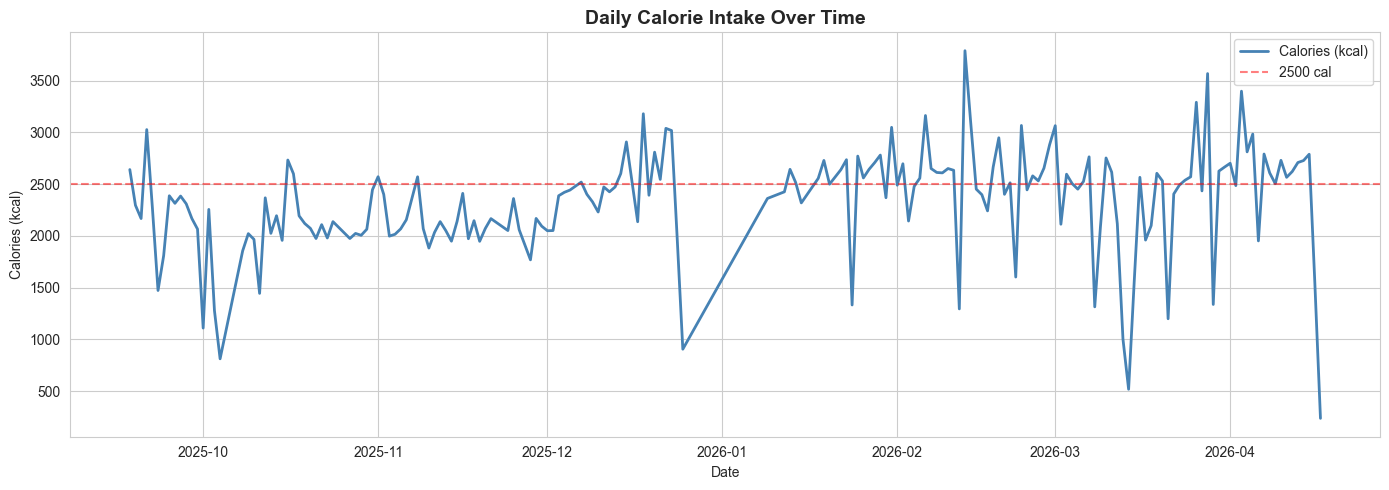

In [27]:
# Daily calories over time
fig, ax = plt.subplots(figsize=(14, 5))
daily_totals['Calories (kcal)'].plot(ax=ax, linewidth=2, color='steelblue')
ax.set_title('Daily Calorie Intake Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Calories (kcal)')
ax.axhline(y=2500, color='r', linestyle='--', alpha=0.5, label='2500 cal')
ax.legend()
plt.tight_layout()
plt.show()

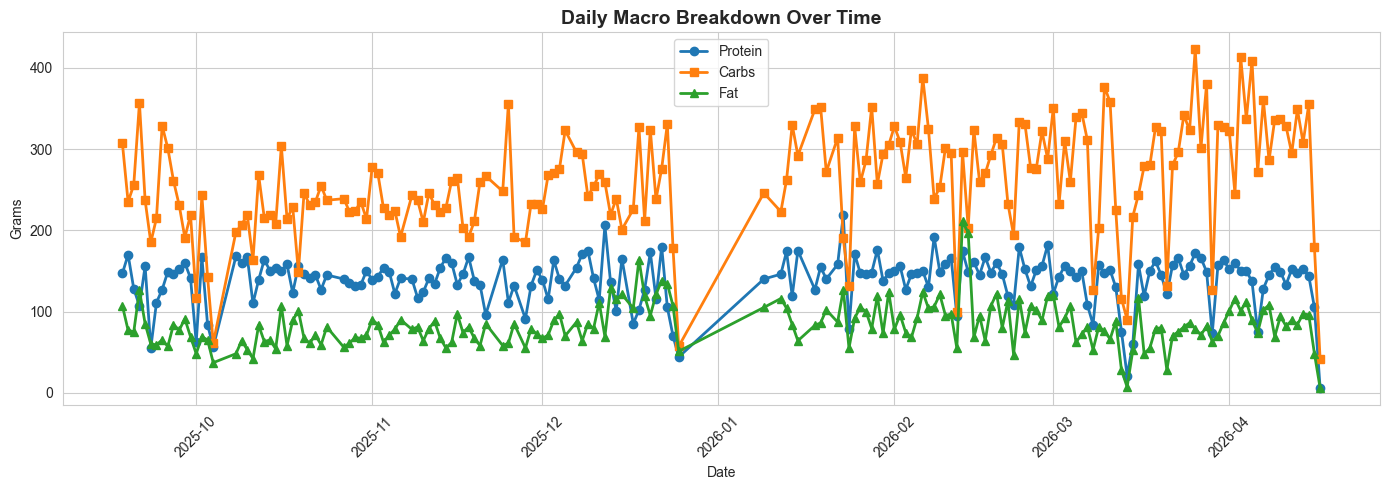

In [28]:
# Macro composition over time
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_totals.index, daily_totals['Protein (g)'], label='Protein', marker='o', linewidth=2)
ax.plot(daily_totals.index, daily_totals['Carbs (g)'], label='Carbs', marker='s', linewidth=2)
ax.plot(daily_totals.index, daily_totals['Fat (g)'], label='Fat', marker='^', linewidth=2)
ax.set_title('Daily Macro Breakdown Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Grams')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

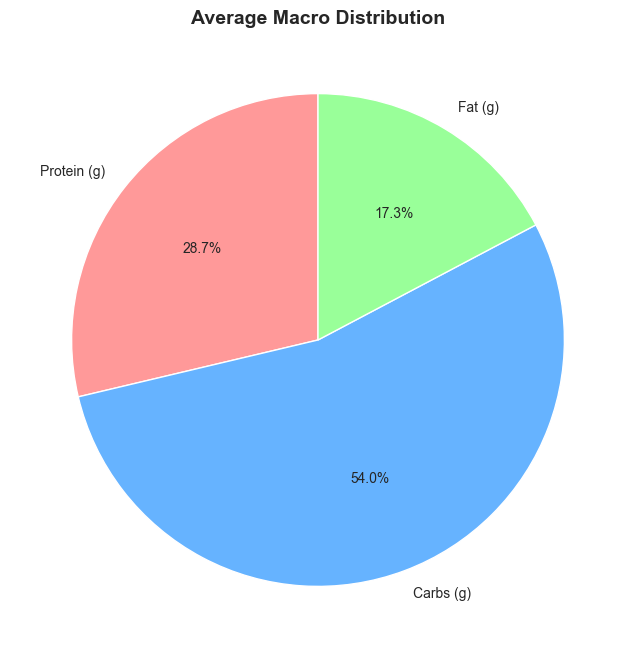

In [29]:
# Average macro pie chart
avg_macros = daily_totals[['Protein (g)', 'Carbs (g)', 'Fat (g)']].mean()
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99']
ax.pie(avg_macros, labels=avg_macros.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Average Macro Distribution', fontsize=14, fontweight='bold')
plt.show()